> This script is deigned to be used with conda env
> crime_weather_env

Code to explore the crimetology_NS.parquet file.
Data created via combine_crime_ceda_data.py.

Good background reading available at [GeoffBoeing.com](https://geoffboeing.com/2014/08/clustering-to-reduce-spatial-data-set-size/)

Optimisation of data processing required as 1.5 million data rows to be clustered with only 16GB of RAM. 

## Import modules

In [33]:
## Typehinting
from _duckdb import DuckDBPyConnection
from pandas.core.frame import DataFrame
from numba.core.types.npytypes import Array

# modules
import time
from pathlib import Path
import numpy as np
import os
import duckdb
from sklearn.cluster import DBSCAN
from pyproj import Transformer
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

## Directories, db and Path Setup

In [2]:
cwd: str = os.getcwd()
data_dir: Path = Path(cwd).parent / 'data' / 'police_archives'
crime_db: Path = data_dir/'crime_archive.db'

Connect to the duckdb

In [3]:
con: DuckDBPyConnection = duckdb.connect(database=crime_db)

Introspect

In [4]:
# introspect
con.execute(query="SHOW TABLES").fetchall()

[('crimetology_NS',),
 ('crimetology_NS_clean',),
 ('crimetology_coords_lookup',),
 ('street_data',)]

In [5]:
con.execute(query="SELECT * FROM crimetology_NS_clean LIMIT 5;").df()


,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,2020-01,0.521596,52.345789,Violence and sexual offences,9.597225,6.834480,8.521248,57.155247,0.028889,4.043394,46.032112,88.652786,4.317238
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,2020-01,1.188665,52.041702,Violence and sexual offences,9.253441,6.699946,12.421773,53.776817,0.017040,4.145340,42.233070,88.948593,4.330167
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,2020-01,0.392886,52.245956,Burglary,9.339664,6.674413,8.760840,60.050930,0.054434,3.973928,49.437729,89.399498,4.221702
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,2020-01,0.694570,52.259155,Violence and sexual offences,9.237802,6.624474,8.096927,60.260311,0.116909,4.029425,52.358356,89.107567,4.471696
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,2020-01,1.335191,51.965723,Violence and sexual offences,9.293962,7.044072,6.509821,56.745304,0.000000,4.690509,31.948408,88.402222,5.864347


In [6]:
## expect this to be 1255500
con.execute(query="SELECT COUNT(*) FROM crimetology_NS_clean LIMIT 5;").df()

,count_star()
0,1255500


In [7]:
con.execute(query="DESCRIBE crimetology_NS_clean").df()

,column_name,column_type,null,key,default,extra
0,Crime ID,VARCHAR,YES,None,None,None
1,Month,VARCHAR,YES,None,None,None
2,Longitude,DOUBLE,YES,None,None,None
3,Latitude,DOUBLE,YES,None,None,None
4,Crime type,VARCHAR,YES,None,None,None
5,tasmax,FLOAT,YES,None,None,None
6,tas,FLOAT,YES,None,None,None
7,groundfrost,FLOAT,YES,None,None,None
8,sun,FLOAT,YES,None,None,None
9,snowLying,FLOAT,YES,None,None,None


In [8]:
con.execute(query="SUMMARIZE crimetology_NS_clean").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,Crime ID,VARCHAR,000006a0d6919a710d3bd0a37d0ff31a0eb99ee5a1c20f...,fffff37e0363180e0780c2208d545e512d90e3de540bd8...,1622925,None,None,None,None,None,1255500,0.0
1,Month,VARCHAR,2016-01,2025-12,136,None,None,None,None,None,1255500,0.0
2,Longitude,DOUBLE,0.300512,1.757943,42131,1.1395494182150399,0.3959295100528411,0.849999341990025,1.1946796688752315,1.3311206503686495,1255500,0.0
3,Latitude,DOUBLE,51.950135,52.972354,52334,52.4397646439887,0.2650787298882885,52.180058138894026,52.52443435319349,52.63640717964827,1255500,0.0
4,Crime type,VARCHAR,Anti-social behaviour,Violence and sexual offences,16,None,None,None,None,None,1255500,0.0
5,tasmax,FLOAT,4.8080764,27.462076,156283,15.435893627845449,5.682904224237646,10.25093565840741,15.100074641826676,20.628739090240405,1255500,0.0
6,tas,FLOAT,2.1268184,20.685835,149424,11.429114954629394,4.8998097611869325,6.924923182662264,11.256318657362236,15.971696411760453,1255500,0.0
7,groundfrost,FLOAT,0.0,26.692324,144181,6.50483007147468,6.642106525202314,0.04500703871505739,4.228498257647558,12.274714856086232,1255500,0.0
8,sun,FLOAT,16.014242,328.6736,213372,149.59287266437983,70.84050654222102,83.69406055884777,155.1329224321294,204.8971475332743,1255500,0.0
9,snowLying,FLOAT,0.0,7.6520123,67539,0.2088989479030356,0.7101793982724235,0.0,0.0,0.036495371162117964,1255500,0.0


The above introspection all looks good

## Prepare data for DBScan

Isolate columns needed for clustering

In [9]:
features_query = """ SELECT "Crime ID",
                             Latitude,
                             Longitude
                     FROM crimetology_NS_clean
                 """
features_df: DataFrame= con.execute(query=features_query).df()

In [10]:
features_df

,Crime ID,Latitude,Longitude
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,52.345789,0.521596
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,52.041702,1.188665
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,52.245956,0.392886
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,52.259155,0.694570
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,51.965723,1.335191
...,...,...,...
1255495,b0817e29e4812387eefd4dbf61223703bd4b2ae18e659e...,52.394576,1.199594
1255496,40f5d31aebde7ecbbb3301ba6f48d58a9fc95fdb77fb2c...,52.375385,1.098691
1255497,bbf00daaa7f12ee2fbff2328b9065555c668f05798d94f...,52.374885,1.096864
1255498,debbfd614bade093a6a6782521caae560f6a5f0565f427...,52.377189,1.098171


HDBScan can be run with metric=havesine, but due to the size of data here I cannot naively run the clustering on the entire 1.5 million rows with the lat/lon method. Switch to euclidean methods so I can take advantage of the sample_weight method to reduce the data dimensionality. 

Transform from latitude/longitude to British National Grid (meters), then create spatial weighting on square areas of events instead of point by point clustering which is very memory heavy. 

In [ ]:
### pyproj transformer
# need to be careful about x and y directions
transformer: Transformer = Transformer.from_crs(crs_from="EPSG:4326", crs_to="EPSG:27700", always_xy=True)


In [12]:
features_df['x_m'], features_df['y_m'] = transformer.transform(xx=features_df['Longitude'].values, yy=features_df['Latitude'].values)

In [20]:
features_df

,Crime ID,Latitude,Longitude,x_m,y_m,grid_x,grid_y
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,52.345789,0.521596,571858.249237,274959.005787,228,109
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,52.041702,1.188665,618774.001407,242942.326342,247,97
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,52.245956,0.392886,563459.181881,263559.242217,225,105
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,52.259155,0.694570,583997.126720,265750.109761,233,106
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,51.965723,1.335191,629208.018156,234946.350104,251,93
...,...,...,...,...,...,...,...
1255495,b0817e29e4812387eefd4dbf61223703bd4b2ae18e659e...,52.394576,1.199594,617790.267388,282209.633966,247,112
1255496,40f5d31aebde7ecbbb3301ba6f48d58a9fc95fdb77fb2c...,52.375385,1.098691,611018.161022,279776.733228,244,111
1255497,bbf00daaa7f12ee2fbff2328b9065555c668f05798d94f...,52.374885,1.096864,610896.210752,279715.810269,244,111
1255498,debbfd614bade093a6a6782521caae560f6a5f0565f427...,52.377189,1.098171,610974.178155,279975.803697,244,111


In [14]:
## now bin to start reducing dimensionality
# put each easting and northing in a 50m**2 box
# 
grid_width = 50  
features_df['grid_x'] = (features_df['x_m'] // (grid_width**2) ).astype(np.int32)
features_df['grid_y'] = (features_df['y_m'] // (grid_width**2) ).astype(np.int32)

In [15]:
features_df

,Crime ID,Latitude,Longitude,x_m,y_m,grid_x,grid_y
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,52.345789,0.521596,571858.249237,274959.005787,228,109
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,52.041702,1.188665,618774.001407,242942.326342,247,97
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,52.245956,0.392886,563459.181881,263559.242217,225,105
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,52.259155,0.694570,583997.126720,265750.109761,233,106
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,51.965723,1.335191,629208.018156,234946.350104,251,93
...,...,...,...,...,...,...,...
1255495,b0817e29e4812387eefd4dbf61223703bd4b2ae18e659e...,52.394576,1.199594,617790.267388,282209.633966,247,112
1255496,40f5d31aebde7ecbbb3301ba6f48d58a9fc95fdb77fb2c...,52.375385,1.098691,611018.161022,279776.733228,244,111
1255497,bbf00daaa7f12ee2fbff2328b9065555c668f05798d94f...,52.374885,1.096864,610896.210752,279715.810269,244,111
1255498,debbfd614bade093a6a6782521caae560f6a5f0565f427...,52.377189,1.098171,610974.178155,279975.803697,244,111


In [ ]:
## now generate sample size per grid box (i.e. how many events are present per grid box)
grid_df: DataFrame = features_df.groupby(by=['grid_x', 'grid_y']).size().reset_index(name='point_count')

In [18]:
grid_df

,grid_x,grid_y,point_count
0,222,102,1
1,222,105,1
2,222,108,3
3,222,113,1
4,222,114,18
...,...,...,...
1508,261,122,22653
1509,261,123,21724
1510,261,124,788
1511,262,117,4505


This method has reduced the dimensionality from:

Point by point data: (1255500 x 2) = 2,511,000 
Gridded data: (1513 x 3) = 4,539

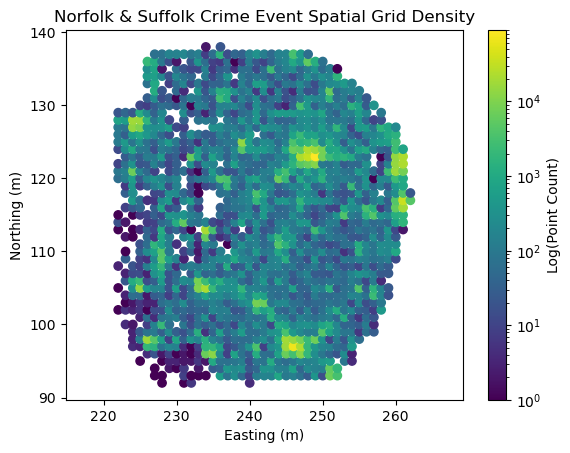

In [34]:
plt.scatter(x=grid_df['grid_x'],y=grid_df['grid_y'],c=grid_df['point_count'],cmap='viridis',norm=LogNorm())
plt.colorbar(label='Log(Point Count)')
plt.title(label='Norfolk & Suffolk Crime Event Spatial Grid Density')
plt.xlabel(xlabel='Easting (m)')
plt.ylabel(ylabel='Northing (m)')
plt.axis('equal')  # Keeps true geographic proportions
plt.show()

## Start DBSCan method

In [36]:
# define epsilon in meters
epsilon: float = float(150)

#definte minimum number of month events to be classifies as a zone
# using the above map color scale - potentailly 100 (into light greens)
min_samples: int = 100